In [1]:
from pathlib import Path
import sys
import os
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.colors as clr
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

from matplotlib.colors import Normalize
import matplotlib.cm as cm
import seaborn as sns

In [2]:
plt.rcParams["figure.figsize"] = (3, 3)
plt.rcParams["figure.dpi"] = 150

## Labeled adata

In [9]:
adata_path01 = "/home/workspace/projects/drg/data/h5ad/export_03/03a_seurat/adata-merged-labels.h5ad"
adata_path02 = "/home/workspace/projects/drg/data/h5ad/export_03/03b_thresholds/adata-labeled.h5ad"

In [7]:
adata_merged_labeled = sc.read_h5ad(adata_path01)

In [10]:
adata_labeled = sc.read_h5ad(adata_path02)

In [11]:
adata_merged_labeled

AnnData object with n_obs × n_vars = 72778 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels', 'cell_type', 'prediction.score.CGRP.Theta', 'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha', 'prediction.score.Nonpeptidergic.nociceptors', 'prediction.score.C.LTMR', 'prediction.score.Sst', 'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion', 'prediction.score.Proprioceptors', 'prediction.score.Unknown', 'prediction.score.Adelta.LTMR', 'prediction.sco

In [12]:
adata_merged_labeled.obsm['X_scVI_ModelA_475'].shape

(72778, 10)

In [13]:
adata_labeled

AnnData object with n_obs × n_vars = 72778 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels', 'cell_type', 'prediction.score.CGRP.Theta', 'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha', 'prediction.score.Nonpeptidergic.nociceptors', 'prediction.score.C.LTMR', 'prediction.score.Sst', 'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion', 'prediction.score.Proprioceptors', 'prediction.score.Unknown', 'prediction.score.Adelta.LTMR', 'prediction.sco

In [14]:
adata_labeled.obs['EGFP_dTomato_dual_hi'].unique().tolist()

[False, True]

In [15]:
sum(adata_labeled.obs['EGFP_dTomato_dual_hi']==True)

5

## Finalize annotations
https://github.com/aifimmunology/spatial_mouse_drg/blob/main/yano/notebooks/04_neurons/02_finalize-annotations.ipynb

In [38]:
# from projects/drg
adata_path03 = "/home/workspace/projects/drg/data/h5ad/export_04/04c_gamma_subtypes/-draft.h5ad"
# from projects/projects/20260115_drg-gpu-backup
adata_path04 = '/home/workspace/projects/20260115_drg-gpu-backup/data/h5ad/export_04/04c_gamma_subtypes/neurons-final-labels.h5ad'

In [39]:
adata_neurons_final_labels_draft = sc.read_h5ad(adata_path03)
adata_neurons_final_labels_backup = sc.read_h5ad(adata_path04)

In [18]:
adata_neurons_final_labels_draft

AnnData object with n_obs × n_vars = 21779 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels', 'cell_type', 'prediction.score.CGRP.Theta', 'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha', 'prediction.score.Nonpeptidergic.nociceptors', 'prediction.score.C.LTMR', 'prediction.score.Sst', 'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion', 'prediction.score.Proprioceptors', 'prediction.score.Unknown', 'prediction.score.Adelta.LTMR', 'prediction.sco

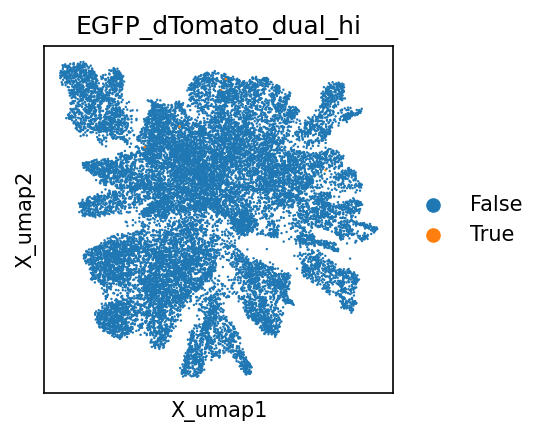

In [19]:
sc.pl.embedding(adata_neurons_final_labels_draft, basis = 'X_umap', color = 'EGFP_dTomato_dual_hi')

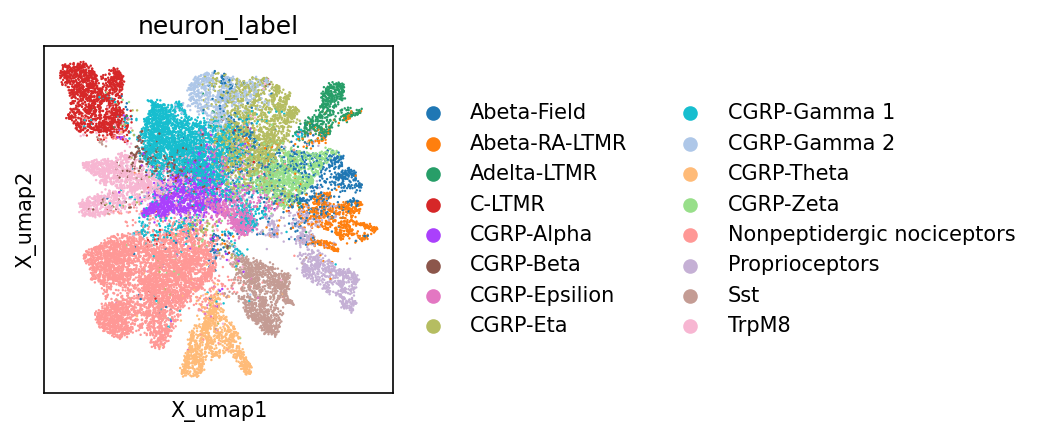

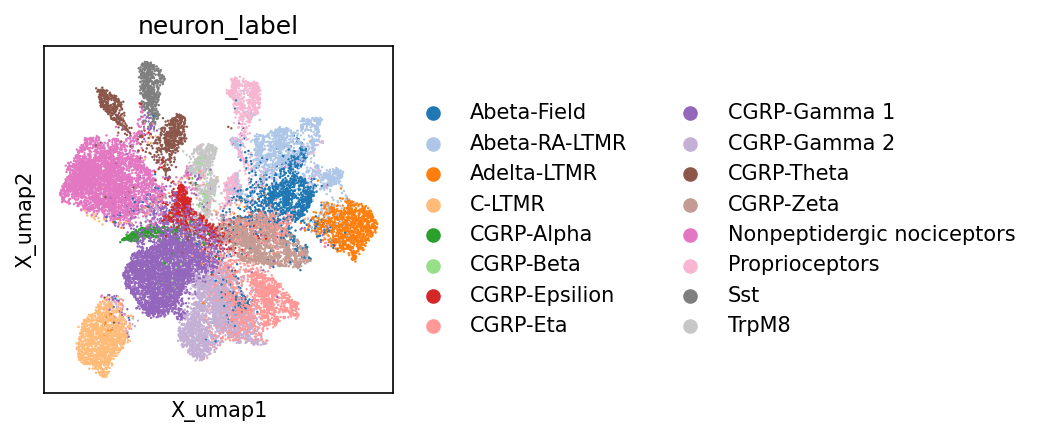

In [37]:
sc.pl.embedding(adata_neurons_final_labels_draft, basis = 'X_umap', color = 'neuron_label')
sc.pl.embedding(adata_neurons_final_labels_backup, basis = 'X_umap', color = 'neuron_label')


In [23]:
import matplotlib.pyplot as plt


def plot_umaps(
    adata,
    label_cols,
    true_color_map,
    false_color,
    true_size,
    false_size,
    edgecolor,
    linewidth,
    alpha_false,
    alpha_true,
    figsize=(3, 3),
):
    """
    Plot minimalist UMAPs for boolean label columns.
    No title, no axes, no border.
    """

    if "X_umap" not in adata.obsm:
        raise ValueError("No UMAP found in adata.obsm['X_umap'].")

    x, y = adata.obsm["X_umap"][:, 0], adata.obsm["X_umap"][:, 1]

    for col in label_cols:
        if col not in adata.obs.columns:
            print(f"Column `{col}` not in adata.obs — skipping.")
            continue

        if col not in true_color_map:
            raise ValueError(f"Missing true_color_map entry for `{col}`.")

        true_color = true_color_map[col]
        mask = adata.obs[col].astype(bool).values

        plt.figure(figsize=figsize)

        # Plot FALSE background
        plt.scatter(
            x[~mask],
            y[~mask],
            s=false_size,
            c=false_color,
            linewidths=0,
            alpha=alpha_false,
        )

        # Plot TRUE foreground
        plt.scatter(
            x[mask],
            y[mask],
            s=true_size,
            c=true_color,
            linewidths=linewidth,
            edgecolors=edgecolor,
            alpha=alpha_true,
        )

        ax = plt.gca()
        ax.set_aspect("equal", "box")

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_title("")  # remove title
        ax.spines["top"].set_visible(False)
        ax.spines["bottom"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.spines["right"].set_visible(False)

        plt.tight_layout()
        plt.show()

In [24]:
labels = ["EGFP_Seq1_hi", "dTomato_Seq2_hi", "EGFP_dTomato_dual_hi"]

true_color_map = {
    "EGFP_Seq1_hi": "limegreen",
    "dTomato_Seq2_hi": "magenta",
    "EGFP_dTomato_dual_hi": "blue",
}

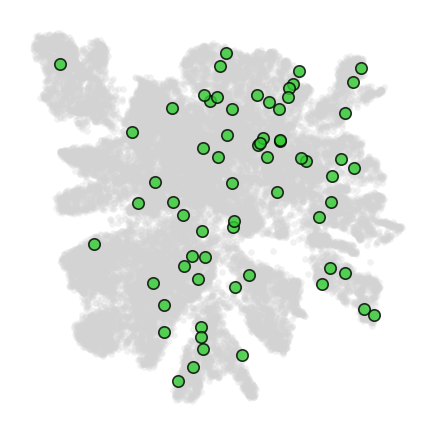

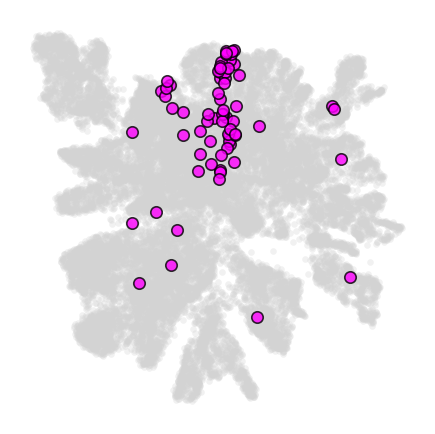

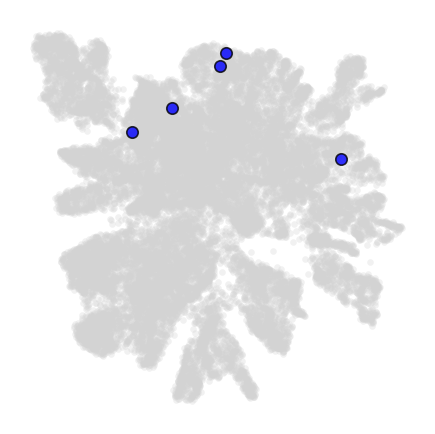

In [25]:
plot_umaps(
    adata_neurons_final_labels_draft,
    label_cols=labels,
    true_color_map=true_color_map,
    false_color="lightgray",
    true_size=30,
    false_size=10,
    edgecolor="black",
    linewidth=0.8,
    alpha_false=0.3,
    alpha_true=0.8,
)

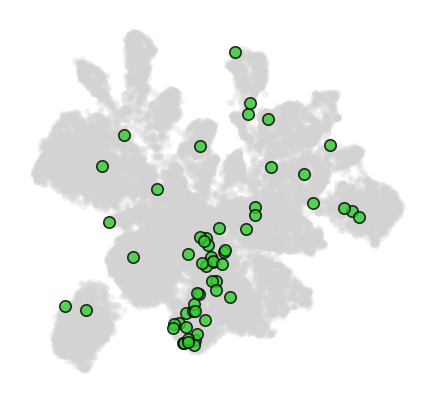

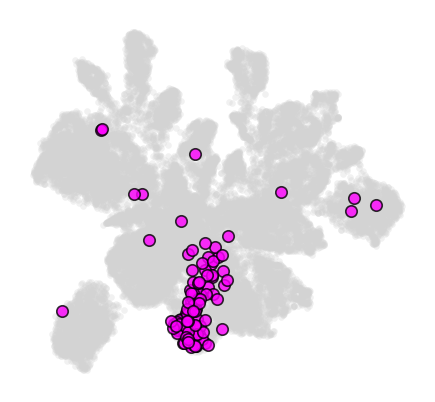

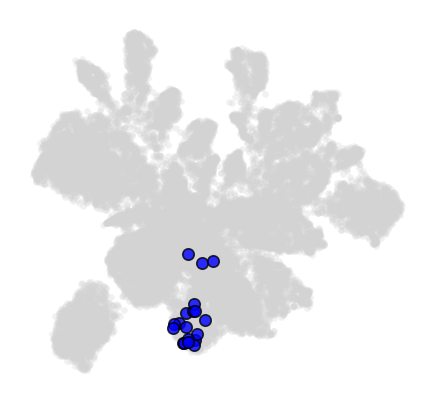

In [41]:
plot_umaps(
    adata_neurons_final_labels_backup,
    label_cols=labels,
    true_color_map=true_color_map,
    false_color="lightgray",
    true_size=30,
    false_size=10,
    edgecolor="black",
    linewidth=0.8,
    alpha_false=0.3,
    alpha_true=0.8,
)

In [29]:
def barplot_dual_distribution(
    adata,
    group_col="neuron_labels",
    dual_col="EGFP_dTomato_dual_hi",
    bar_color="black",
    figsize=(4, 2),
    fontsize=11,
):
    df = adata.obs[[group_col, dual_col]].copy()
    df[dual_col] = df[dual_col].astype(bool)
    df[group_col] = df[group_col].astype(str).replace("nan", "Unknown")

    # Count dual positives per group (correct)
    dual_counts = df.groupby(group_col)[dual_col].sum()

    total_dual = dual_counts.sum()

    # Correct percentage
    stats = (dual_counts / total_dual * 100).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(len(stats))
    ax.bar(x, stats.values, color=bar_color, alpha=0.9)

    # xticks
    ax.set_xticks(x)
    ax.set_xticklabels(stats.index, rotation=90, ha="right", fontsize=fontsize)

    # y-axis
    ax.set_ylim(0, 100)  # <-- force axis to show full 0–100%
    ax.set_ylabel("% of Double+ \nneurons", fontsize=fontsize)
    ax.set_xlabel("")

    # minimalist styling
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", length=0)

    plt.subplots_adjust(bottom=0.28)
    return fig

In [30]:
adata_neurons_final_labels_draft.obs.EGFP_dTomato_dual_hi.value_counts()

EGFP_dTomato_dual_hi
False    21774
True         5
Name: count, dtype: int64

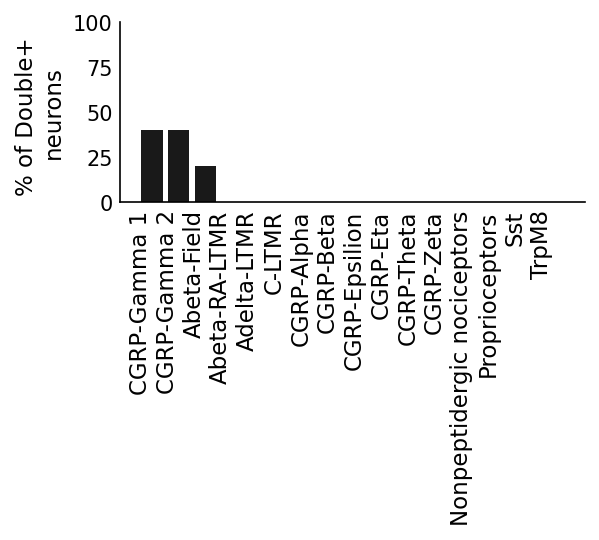

In [31]:
fig = barplot_dual_distribution(adata_neurons_final_labels_draft)

## Export Neuron annotations for Xenium Explorer 
- To get the barcodes to match in xenium explorer, we need to separate into individual Xenium outputs and remove the trailing -0, -1, -2, or -3

In [92]:
adata_neurons_final_labels_draft.obs['sample_id'].unique()

['TMA00317', 'TMA00315', 'TMA00318', 'TMA00316']
Categories (4, object): ['TMA00315', 'TMA00316', 'TMA00317', 'TMA00318']

### Make label annotations df

In [93]:
label_cols = ["sample_id","neuron_label","EGFP_Seq1_hi", "dTomato_Seq2_hi", "EGFP_dTomato_dual_hi"]
label_df = adata_neurons_final_labels_draft.obs[label_cols]

index_clipped = ["-".join(barcode.split('-')[0:2]) for barcode in label_df.index]
label_df.index = index_clipped
label_df = label_df.reset_index(names='cell_id')

In [94]:
label_df.head()

,cell_id,sample_id,neuron_label,EGFP_Seq1_hi,dTomato_Seq2_hi,EGFP_dTomato_dual_hi
0,aaahbdia-1,TMA00317,Nonpeptidergic nociceptors,False,False,False
1,aaakgcko-1,TMA00317,Abeta-RA-LTMR,False,False,False
2,aaanbmpi-1,TMA00317,Nonpeptidergic nociceptors,False,False,False
3,aaangnjd-1,TMA00317,Adelta-LTMR,False,False,False
4,aabakkkd-1,TMA00317,CGRP-Eta,False,False,False


### save neuron labels for Xenium explorer

In [95]:
# for Xenium explorer, can only have one group
label_df_neuron_label = label_df.copy()
label_df_neuron_label['group'] = label_df_neuron_label['neuron_label']

# split to individual samples
label_df_TMA00315 = label_df_neuron_label[label_df_neuron_label['sample_id']=='TMA00315']
label_df_TMA00316 = label_df_neuron_label[label_df_neuron_label['sample_id']=='TMA00316']
label_df_TMA00317 = label_df_neuron_label[label_df_neuron_label['sample_id']=='TMA00317']
label_df_TMA00318 = label_df_neuron_label[label_df_neuron_label['sample_id']=='TMA00318']

# save to csv 
label_df_TMA00315.to_csv('label_df_TMA00315_neuron_label.csv',index=False)
label_df_TMA00316.to_csv('label_df_TMA00316_neuron_label.csv',index=False)
label_df_TMA00317.to_csv('label_df_TMA00317_neuron_label.csv',index=False)
label_df_TMA00318.to_csv('label_df_TMA00318_neuron_label.csv',index=False)

### save reporter group for Xenium explorer




In [96]:
# for Xenium explorer, can only have one group
label_df_reporter = label_df.copy()
label_df_reporter['group'] = 'none'

# add reporter status, either single positive or double postivie
label_df_reporter.loc[label_df_reporter['EGFP_Seq1_hi']==True, 'group'] = 'EGFP_Seq1_hi'
label_df_reporter.loc[label_df_reporter['dTomato_Seq2_hi']==True, 'group'] = 'dTomato_Seq2_hi'
label_df_reporter.loc[label_df_reporter['EGFP_dTomato_dual_hi']==True, 'group'] = 'EGFP_dTomato_dual_hi'

# split to individual samples
label_df_TMA00315 = label_df_reporter[label_df_reporter['sample_id']=='TMA00315']
label_df_TMA00316 = label_df_reporter[label_df_reporter['sample_id']=='TMA00316']
label_df_TMA00317 = label_df_reporter[label_df_reporter['sample_id']=='TMA00317']
label_df_TMA00318 = label_df_reporter[label_df_reporter['sample_id']=='TMA00318']

# save to csv 
label_df_TMA00315.to_csv('label_df_TMA00315_reporter_label.csv',index=False)
label_df_TMA00316.to_csv('label_df_TMA00316_reporter_label.csv',index=False)
label_df_TMA00317.to_csv('label_df_TMA00317_reporter_label.csv',index=False)
label_df_TMA00318.to_csv('label_df_TMA00318_reporter_label.csv',index=False)

In [98]:
# check with sample the double positive cells are in
counts = label_df.value_counts(['sample_id', 'EGFP_dTomato_dual_hi'])
counts

sample_id  EGFP_dTomato_dual_hi
TMA00316   False                   6076
TMA00315   False                   5954
TMA00318   False                   5046
TMA00317   False                   4698
TMA00316   True                       3
TMA00315   True                       1
TMA00318   True                       1
Name: count, dtype: int64